TRAINING TENSORFLOW ANN MODEL


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 128)                 │           2,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,825 (54.00 KB)

 Trainable params: 13,825 (54.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
616/616 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8726 - loss: 0.3379 - val_accuracy: 0.8803 - val_loss: 0.2929
Epoch 2/30
616/616 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8786 - loss: 0.3099 - val_accuracy: 0.8903 - val_loss: 0.2942
Epoch 3/30
616/616 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8832 - loss: 0.3044 - val_accuracy: 0.8940 - val_loss: 0.2864
Epoch 4/30
616/616 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8830 - loss: 0.3015 - val_accuracy: 0.8899 - val_loss: 0.2830
Epoch 5/30
616/616 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8840 - loss: 0.3004 - val_accuracy: 0.8940 - val_loss: 0.2788
Epoch 6/30
616/616 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8863 - loss: 0.2966 - val_accuracy: 0.8940 - val_loss: 0.2808
Epoch 7/30
616/616 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8864 - loss: 0.2947 - val_accuracy: 0.8972 - val_loss: 0.2818
Epoch 8/30
616/616 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8888 - loss: 0.2922 - val_accuracy: 0.

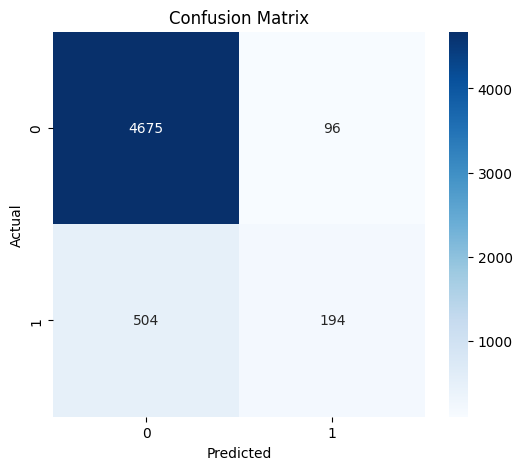


Confusion Matrix:
[[4675   96]
 [ 504  194]]


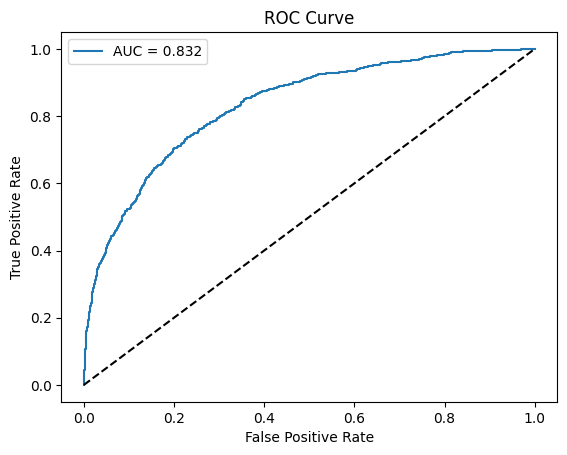


✅ TensorFlow model saved!


In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, QuantileTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# TensorFlow
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)

print("="*50)
print("TRAINING TENSORFLOW ANN MODEL")
print("="*50)

# ============================================
# 1. LOAD DATA
# ============================================
df = pd.read_csv(r"C:\Rainproj\rain.csv")

# ============================================
# 2. PREPROCESSING (SAME AS YOUR CODE)
# ============================================
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df['Month'] = df['Date'].dt.month
    df.drop('Date', axis=1, inplace=True)

df = df.dropna(subset=['RainTomorrow'])
df['RainTomorrow'] = df['RainTomorrow'].map({'Yes': 1, 'No': 0})

categorical_cols = df.select_dtypes(include=['object', 'string']).columns
label_encoders = {}

for col in categorical_cols:
    df[col] = df[col].fillna('Unknown')
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

X = df.drop('RainTomorrow', axis=1)
y = df['RainTomorrow']

numerical_cols = X.select_dtypes(include=[np.number]).columns

imputer = SimpleImputer(strategy='median')
X[numerical_cols] = imputer.fit_transform(X[numerical_cols])

# Outlier removal
def remove_outliers_iqr(df, columns):
    df_clean = df.copy()
    for col in columns:
        Q1 = df_clean[col].quantile(0.25)
        Q3 = df_clean[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df_clean = df_clean[(df_clean[col] >= lower) & (df_clean[col] <= upper)]
    return df_clean

X = remove_outliers_iqr(X, numerical_cols)
y = y[X.index]

# Quantile Transform
qt = QuantileTransformer(output_distribution='uniform', random_state=42)
X[numerical_cols] = qt.fit_transform(X[numerical_cols])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================
# 3. BUILD TENSORFLOW ANN
# ============================================
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))

model.add(Dense(1, activation='sigmoid'))  # binary output

# Compile
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ============================================
# 4. TRAIN MODEL
# ============================================
early_stop = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    X_train_scaled, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

# ============================================
# 5. EVALUATION
# ============================================
y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\n" + "="*40)
print("TENSORFLOW ANN PERFORMANCE")
print("="*40)
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")

# ============================================
# CONFUSION MATRIX VISUALIZATION
# ============================================
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC + AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc = roc_auc_score(y_test, y_pred_prob)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()
# ============================================
# 6. SAVE MODEL
# ============================================
model.save("tf_rain_model.h5")

# Save preprocessing
model_objects = {
    'scaler': scaler,
    'imputer': imputer,
    'qt': qt,
    'label_encoders': label_encoders,
    'feature_columns': X.columns.tolist()
}

with open('preprocessing.pkl', 'wb') as f:
    pickle.dump(model_objects, f)

print("\n✅ TensorFlow model saved!")